In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [2]:
df = pd.read_csv(r"C:\Users\Rikku\Downloads\Nassau Candy Distributor.csv")
print("Dataset Loaded!  Shape:", df.shape)
df.head()

Dataset Loaded!  Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

Duplicates: 0


In [5]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
print("Date columns converted!")
print("Order Date range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Ship  Date range:", df['Ship Date'].min(),  "to", df['Ship Date'].max())

Date columns converted!
Order Date range: 2024-01-02 00:00:00 to 2025-12-31 00:00:00
Ship  Date range: 2026-06-30 00:00:00 to 2030-06-28 00:00:00


In [7]:
df['Lead Time']     = (df['Ship Date'] - df['Order Date']).dt.days
df['Month']         = df['Order Date'].dt.month
df['Year']          = df['Order Date'].dt.year
df['Quarter']       = df['Order Date'].dt.quarter
df['Profit Margin'] = (df['Gross Profit'] / df['Sales']) * 100
print("Feature Engineering Done!")
df[['Lead Time','Month','Year','Quarter','Profit Margin']].head()

Feature Engineering Done!


,Lead Time,Month,Year,Quarter,Profit Margin
0,909,1,2024,1,64.923077
1,909,1,2024,1,65.333333
2,909,1,2024,1,71.346705
3,909,1,2024,1,69.444444
4,912,1,2024,1,65.333333


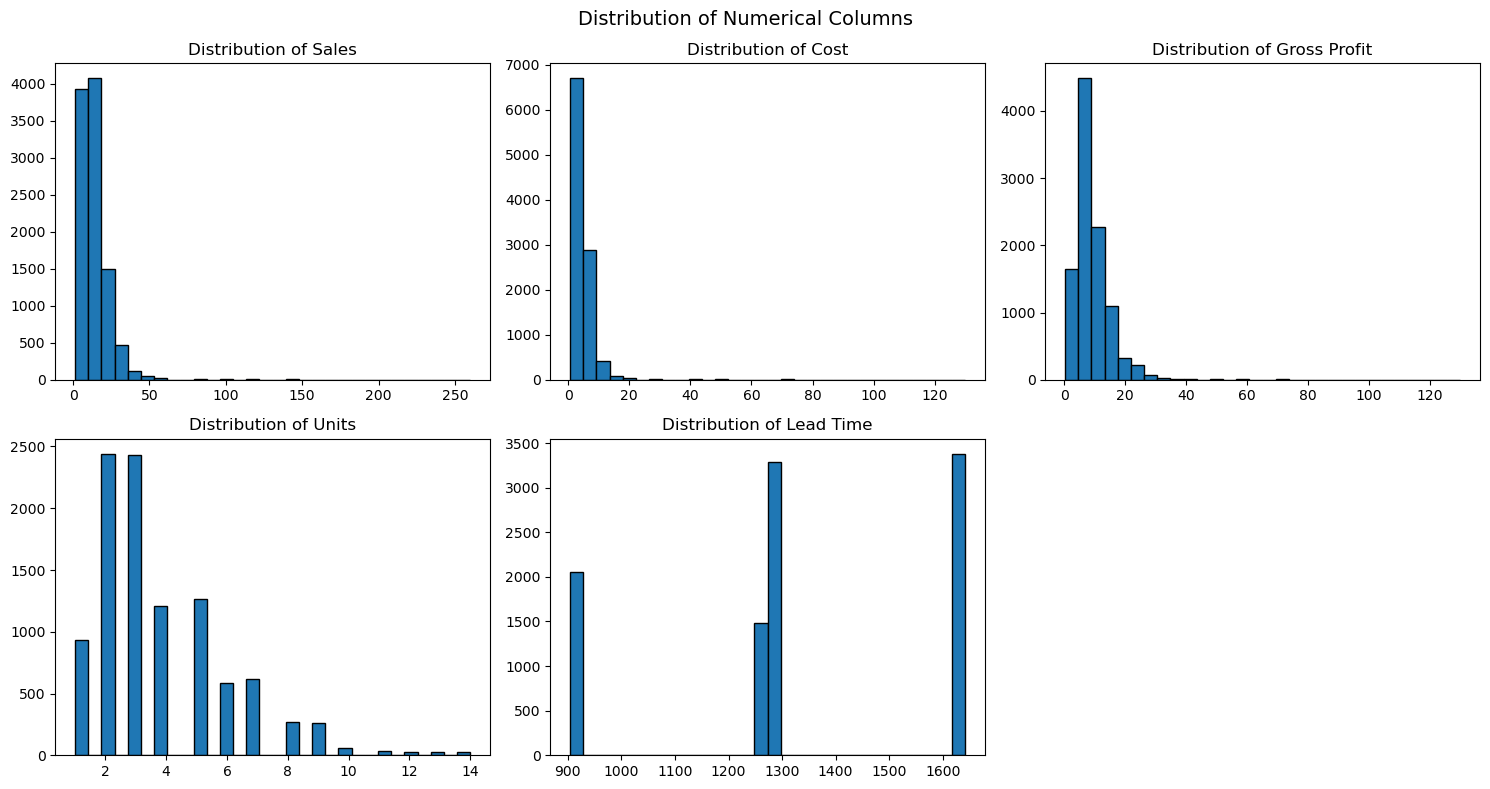

In [8]:
num_cols = ['Sales','Cost','Gross Profit','Units','Lead Time']
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.suptitle('Distribution of Numerical Columns', fontsize=14)
plt.tight_layout(); plt.show()

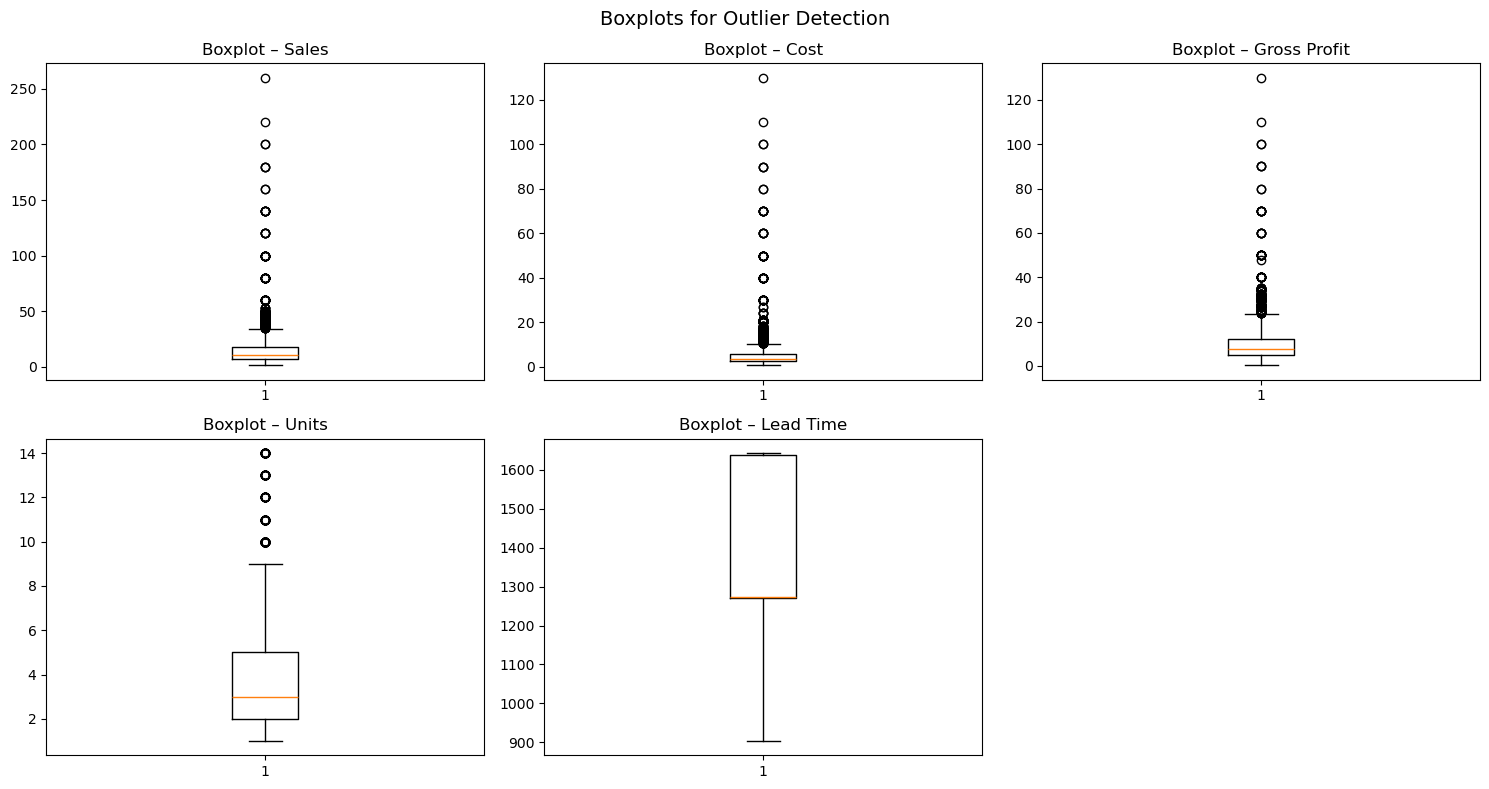

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot – {col}')
axes[-1].axis('off')
plt.suptitle('Boxplots for Outlier Detection', fontsize=14)
plt.tight_layout(); plt.show()

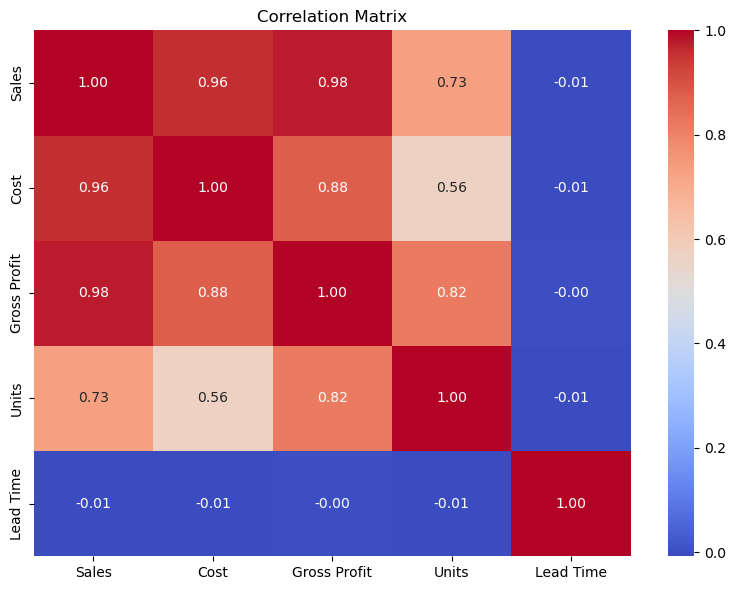

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

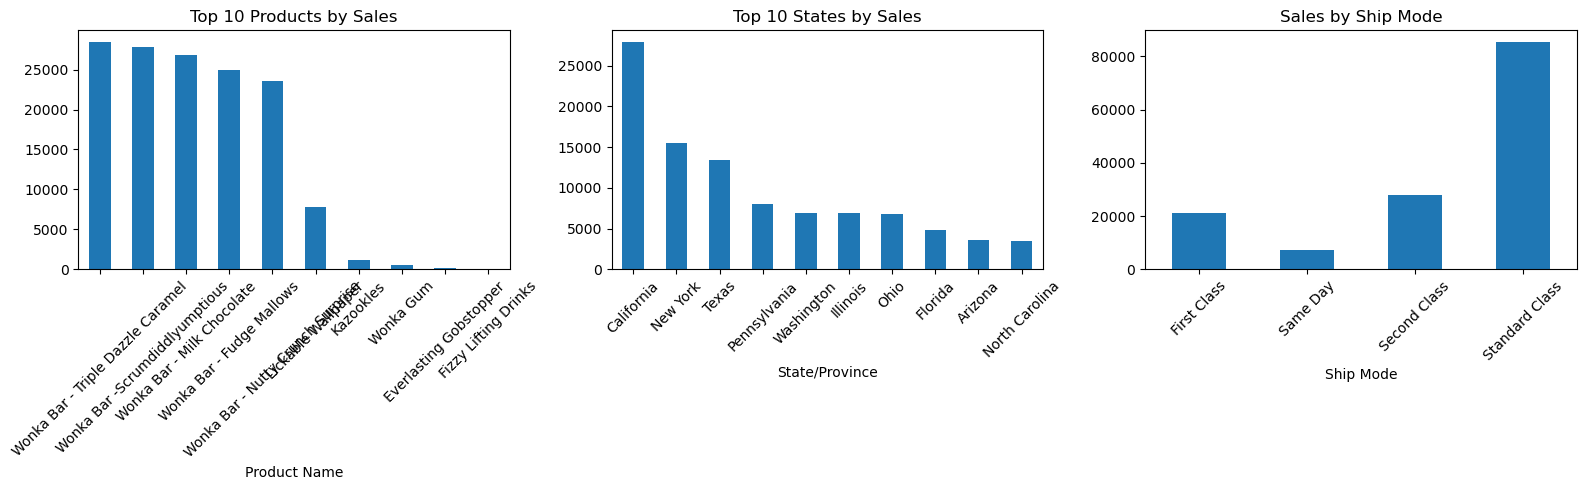

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[0], title='Top 10 Products by Sales')
df.groupby('State/Province')['Sales'].sum().sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], title='Top 10 States by Sales')
df.groupby('Ship Mode')['Sales'].sum().plot(kind='bar', ax=axes[2], title='Sales by Ship Mode')
for ax in axes: ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

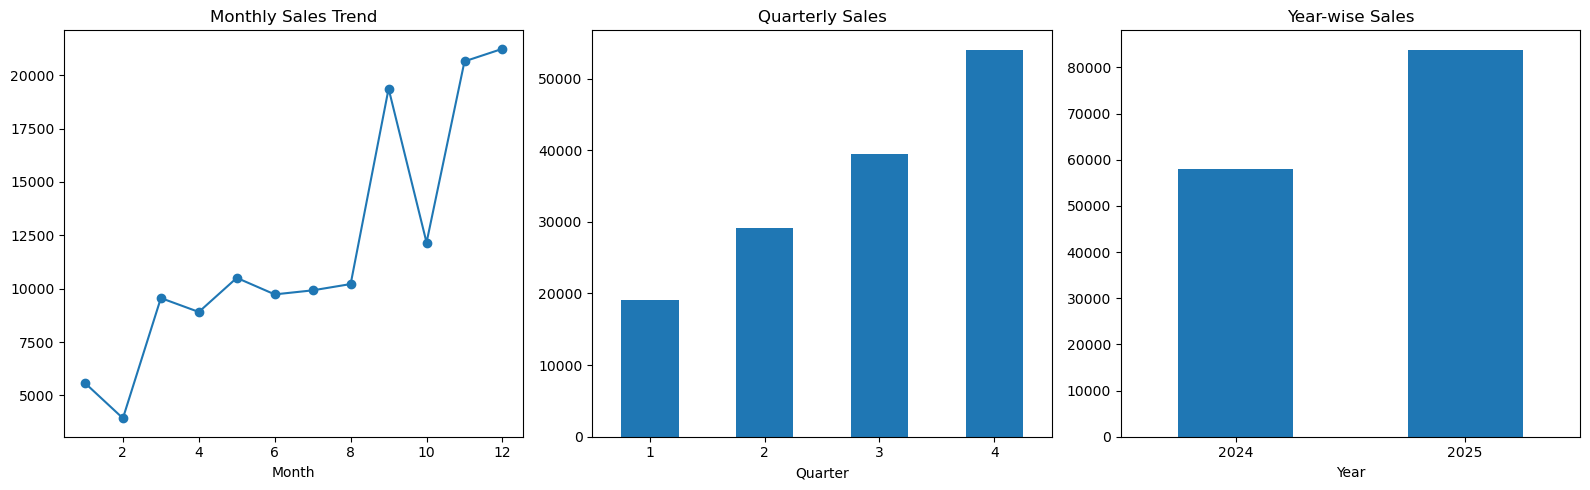

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
df.groupby('Month')['Sales'].sum().plot(marker='o', ax=axes[0], title='Monthly Sales Trend')
df.groupby('Quarter')['Sales'].sum().plot(kind='bar', ax=axes[1], title='Quarterly Sales')
df.groupby('Year')['Sales'].sum().plot(kind='bar', ax=axes[2], title='Year-wise Sales')
for ax in axes: ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

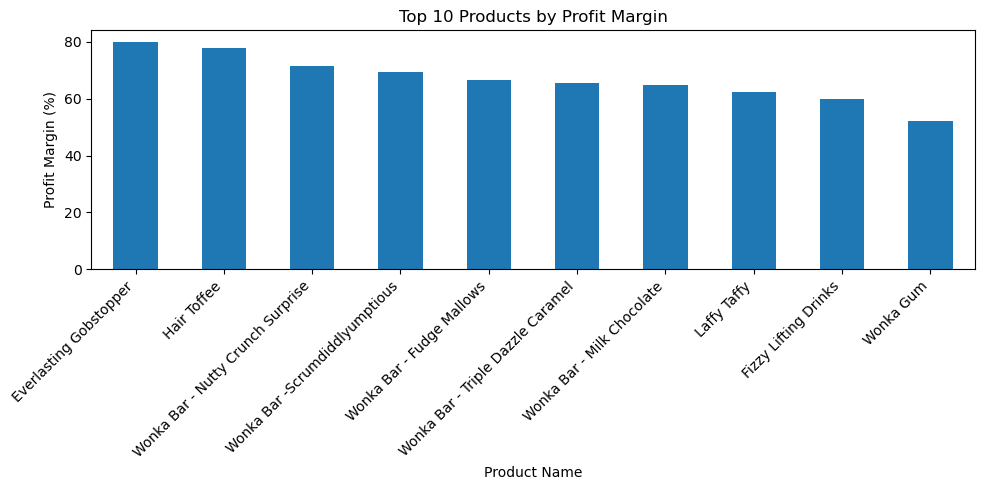

In [13]:
df.groupby('Product Name')['Profit Margin'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10,5), title='Top 10 Products by Profit Margin')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [14]:
for col in ['Sales','Cost','Gross Profit','Units']:
    Q1  = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    df  = df[(df[col] >= Q1-1.5*IQR) & (df[col] <= Q3+1.5*IQR)]
print("Outliers Removed!  New Shape:", df.shape)

Outliers Removed!  New Shape: (9783, 23)


In [15]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise" : "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows"         : "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious"    : "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate"        : "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel" : "Wicked Choccy's",
    "Laffy Taffy"         : "Sugar Shack",
    "SweeTARTS"           : "Sugar Shack",
    "Nerds"               : "Sugar Shack",
    "Fun Dip"             : "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee"         : "The Other Factory",
    "Lickable Wallpaper"  : "Secret Factory",
    "Wonka Gum"           : "Secret Factory",
    "Kazookles"           : "The Other Factory"
}
factory_coordinates = {
    "Lot's O' Nuts"    : (32.881893,-111.768036),
    "Wicked Choccy's"  : (32.076176, -81.088371),
    "Sugar Shack"      : (48.119140, -96.181150),
    "Secret Factory"   : (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107)
}
df["Factory"]           = df["Product Name"].map(factory_mapping)
df["Factory Latitude"]  = df["Factory"].map(lambda x: factory_coordinates[x][0])
df["Factory Longitude"] = df["Factory"].map(lambda x: factory_coordinates[x][1])
print("Factory Mapping Done!  Null:", df["Factory"].isnull().sum())
df[["Product Name","Factory"]].drop_duplicates().reset_index(drop=True)

Factory Mapping Done!  Null: 0


,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Fudge Mallows,Lot's O' Nuts
5,Wonka Gum,Secret Factory
6,Kazookles,The Other Factory
7,Fizzy Lifting Drinks,Sugar Shack
8,Laffy Taffy,Sugar Shack
9,SweeTARTS,Sugar Shack


In [16]:
X = df.drop(["Lead Time","Row ID","Order ID","Customer ID",
              "Order Date","Ship Date","Factory"], axis=1)
y = df["Lead Time"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
print("Categorical cols:", cat_cols)
print("X shape:", X.shape)

Categorical cols: ['Ship Mode', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name']
X shape: (9783, 19)


In [17]:
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
print("All columns encoded!")
print("Regions     :", encoders["Region"].classes_.tolist())
print("Ship Modes  :", encoders["Ship Mode"].classes_.tolist())

All columns encoded!
Regions     : ['Atlantic', 'Gulf', 'Interior', 'Pacific']
Ship Modes  : ['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "  X_test:", X_test.shape)

X_train: (7826, 19)   X_test: (1957, 19)


In [19]:
scale_cols = ["Sales","Cost","Gross Profit","Units",
              "Month","Quarter","Year","Profit Margin"]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])
print("Scaling Done!")
X_train.head()

Scaling Done!


,Ship Mode,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Month,Year,Quarter,Profit Margin,Factory Latitude,Factory Longitude
9677,3,1,96,14,223,0,2,4,11,-0.198880,-0.313441,-0.241114,-0.102448,0.970663,0.83325,1.056124,-0.291144,32.076176,-81.088371
5016,1,1,270,5,516,0,3,0,8,0.801408,0.734397,0.764103,0.846603,-0.546071,0.83325,-0.826187,-0.047844,32.881893,-111.768036
8675,0,1,28,21,49,0,0,2,10,1.754276,1.782235,1.937938,1.298532,0.363970,0.83325,0.114969,0.806147,32.881893,-111.768036
4585,3,1,445,5,577,0,3,4,11,-0.198880,-0.313441,-0.241114,-0.102448,-1.152764,0.83325,-0.826187,-0.291144,32.076176,-81.088371
631,3,1,385,51,391,0,2,1,9,0.060454,0.210478,-0.005483,0.195825,-0.546071,-1.20012,-0.826187,-0.366005,32.076176,-81.088371


In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train); lr_pred = lr.predict(X_test)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
print("=== Linear Regression ===")
print(f"MAE:{lr_mae:.4f}  RMSE:{lr_rmse:.4f}  R2:{lr_r2:.4f}")

=== Linear Regression ===
MAE:181.7397  RMSE:182.8822  R2:0.5121


In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train); rf_pred = rf.predict(X_test)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)
print("=== Random Forest ===")
print(f"MAE:{rf_mae:.4f}  RMSE:{rf_rmse:.4f}  R2:{rf_r2:.4f}")

=== Random Forest ===
MAE:150.2810  RMSE:167.6963  R2:0.5898


In [22]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train); gb_pred = gb.predict(X_test)
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2   = r2_score(y_test, gb_pred)
print("=== Gradient Boosting ===")
print(f"MAE:{gb_mae:.4f}  RMSE:{gb_rmse:.4f}  R2:{gb_r2:.4f}")

=== Gradient Boosting ===
MAE:177.4857  RMSE:180.3614  R2:0.5255


In [23]:
comparison = pd.DataFrame({
    "Model"   : ["Linear Regression","Random Forest","Gradient Boosting"],
    "MAE"     : [lr_mae, rf_mae, gb_mae],
    "RMSE"    : [lr_rmse,rf_rmse,gb_rmse],
    "R2 Score": [lr_r2,  rf_r2,  gb_r2]
})
print(comparison.to_string(index=False))

            Model        MAE       RMSE  R2 Score
Linear Regression 181.739716 182.882220  0.512149
    Random Forest 150.281022 167.696282  0.589804
Gradient Boosting 177.485746 180.361409  0.525505


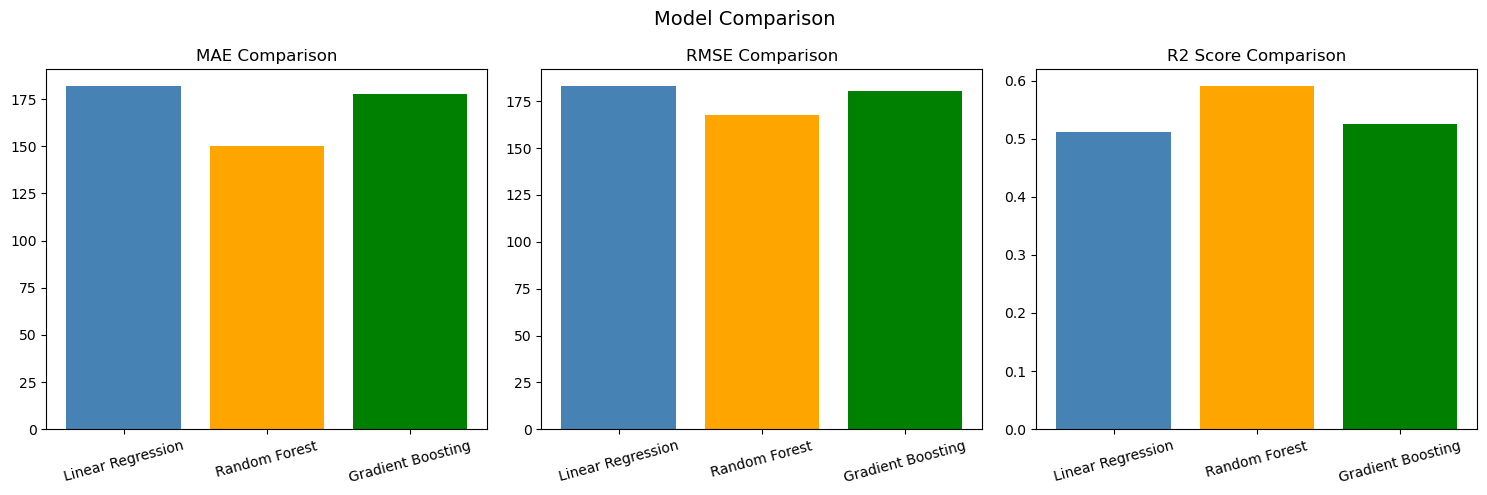

In [24]:
fig, axes = plt.subplots(1,3, figsize=(15,5))
colors = ['steelblue','orange','green']
for ax, metric in zip(axes, ["MAE","RMSE","R2 Score"]):
    ax.bar(comparison["Model"], comparison[metric], color=colors)
    ax.set_title(f"{metric} Comparison")
    ax.tick_params(axis='x', rotation=15)
plt.suptitle("Model Comparison", fontsize=14)
plt.tight_layout(); plt.show()

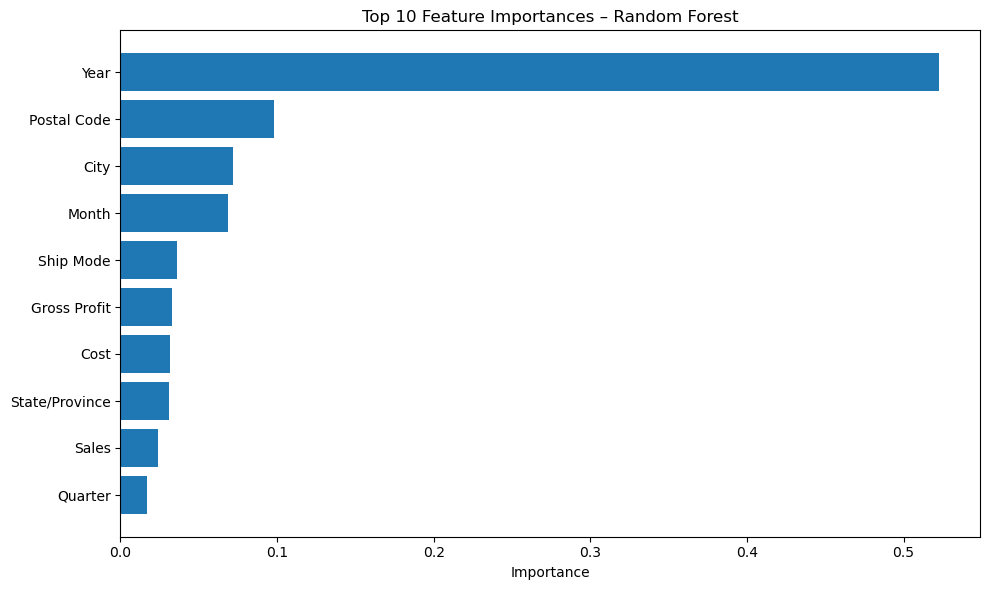

In [25]:
fi = pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_}
    ).sort_values("Importance", ascending=False)
plt.figure(figsize=(10,6))
plt.barh(fi["Feature"].head(10), fi["Importance"].head(10))
plt.xlabel("Importance"); plt.title("Top 10 Feature Importances – Random Forest")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

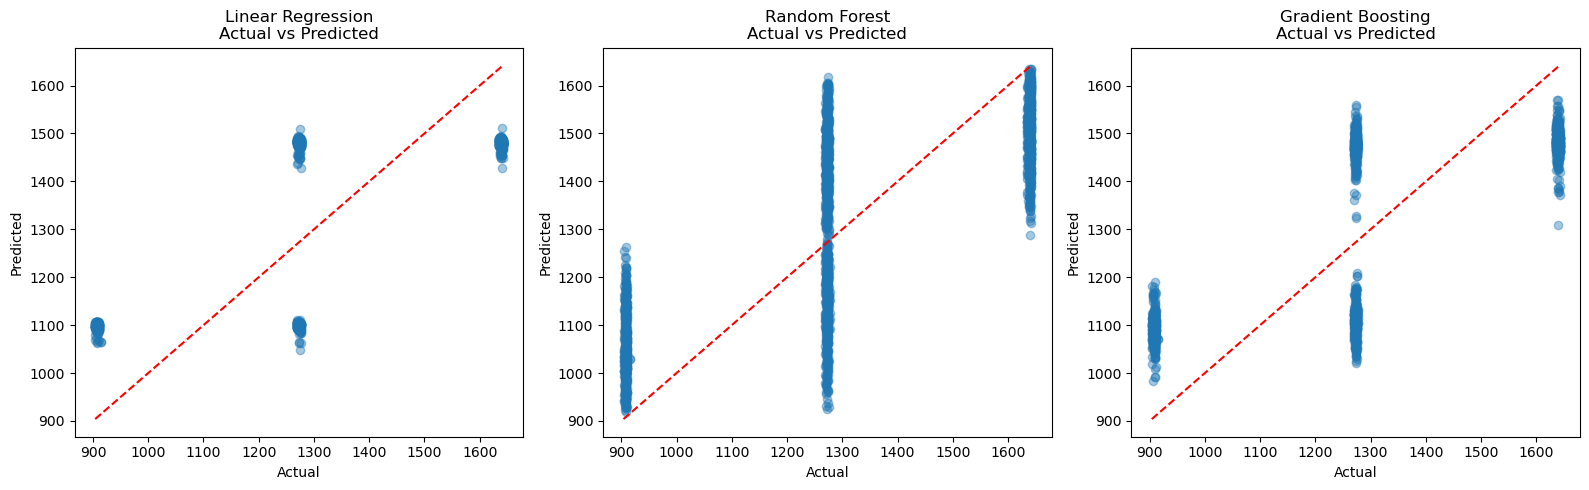

In [26]:
fig, axes = plt.subplots(1,3, figsize=(16,5))
for ax, pred, title in zip(axes,
    [lr_pred, rf_pred, gb_pred],
    ["Linear Regression","Random Forest","Gradient Boosting"]):
    ax.scatter(y_test, pred, alpha=0.4)
    ax.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
    ax.set_title(f"{title}\nActual vs Predicted")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
plt.tight_layout(); plt.show()

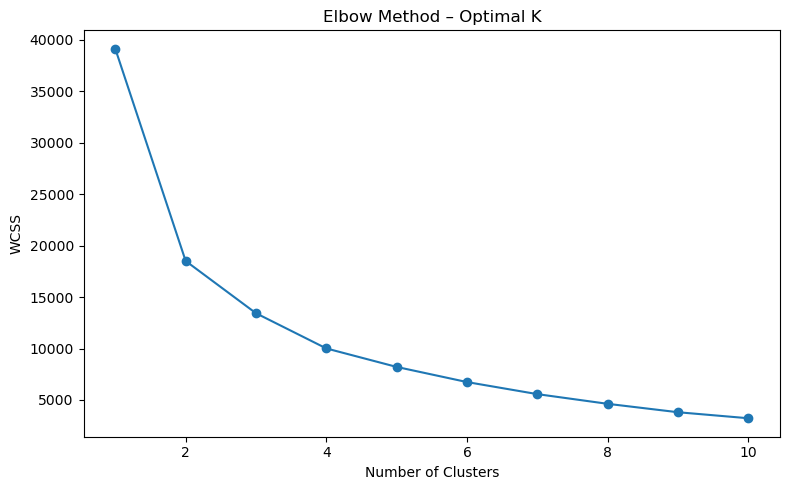

In [27]:
cluster_data   = df[['Lead Time','Sales','Gross Profit','Units']]
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled); wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method – Optimal K')
plt.xlabel('Number of Clusters'); plt.ylabel('WCSS')
plt.tight_layout(); plt.show()

In [28]:
kmeans        = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(cluster_scaled)
cluster_names = {0:"Fast Route",1:"Moderate Route",
                 2:"High Value Route",3:"Critical Slow Route"}
df["Cluster Name"] = df["Cluster"].map(cluster_names)
print("Clustering Done!")
print(df["Cluster Name"].value_counts())

Clustering Done!
Cluster Name
Fast Route             3941
Moderate Route         2409
Critical Slow Route    1996
High Value Route       1437
Name: count, dtype: int64


In [29]:
cluster_summary = df.groupby("Cluster Name")[
    ["Lead Time","Sales","Gross Profit","Units"]].mean().round(2)
print(cluster_summary)

                     Lead Time  Sales  Gross Profit  Units
Cluster Name                                              
Critical Slow Route    1638.83   8.00          5.35   2.32
Fast Route             1158.62   8.03          5.36   2.31
High Value Route       1318.06  25.04         16.96   7.08
Moderate Route         1326.03  16.28         10.97   4.64


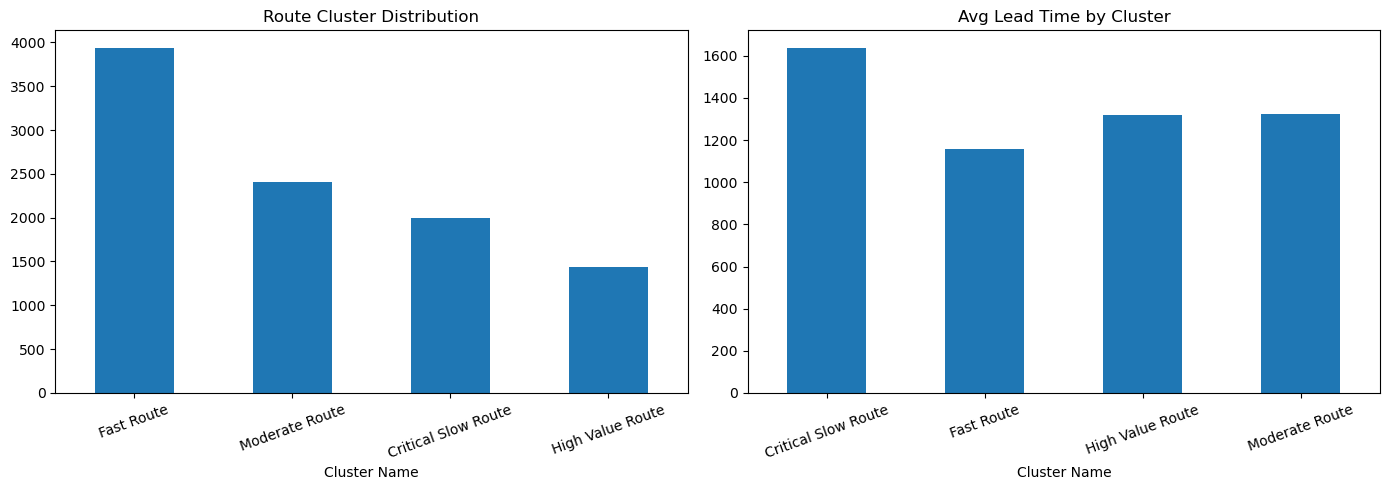

In [30]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
df["Cluster Name"].value_counts().plot(kind='bar', ax=axes[0],
    title='Route Cluster Distribution')
df.groupby("Cluster Name")["Lead Time"].mean().plot(kind='bar', ax=axes[1],
    title='Avg Lead Time by Cluster')
for ax in axes: ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [31]:
region_product = df.groupby(["Region","Product Name"]).agg(
    Avg_Lead_Time=("Lead Time","mean"),
    Order_Count=("Order ID","count")
).reset_index()

congested = region_product[
    region_product["Avg_Lead_Time"] > region_product["Avg_Lead_Time"].quantile(0.75)
].sort_values("Avg_Lead_Time", ascending=False)

print("Congested Region-Product Combinations (Slow Routes):")
print(congested.head(10).to_string(index=False))

Congested Region-Product Combinations (Slow Routes):
  Region                      Product Name  Avg_Lead_Time  Order_Count
Interior                Lickable Wallpaper    1641.000000            1
Atlantic                       Hair Toffee    1639.000000            1
 Pacific                       Laffy Taffy    1638.000000            1
 Pacific                         SweeTARTS    1638.000000            1
    Gulf                       Hair Toffee    1635.000000            1
Atlantic                       Laffy Taffy    1456.166667            6
Atlantic              Fizzy Lifting Drinks    1455.500000            2
Atlantic                Lickable Wallpaper    1394.000000            3
Interior                         SweeTARTS    1364.750000            4
Atlantic Wonka Bar - Nutty Crunch Surprise    1361.099585          482


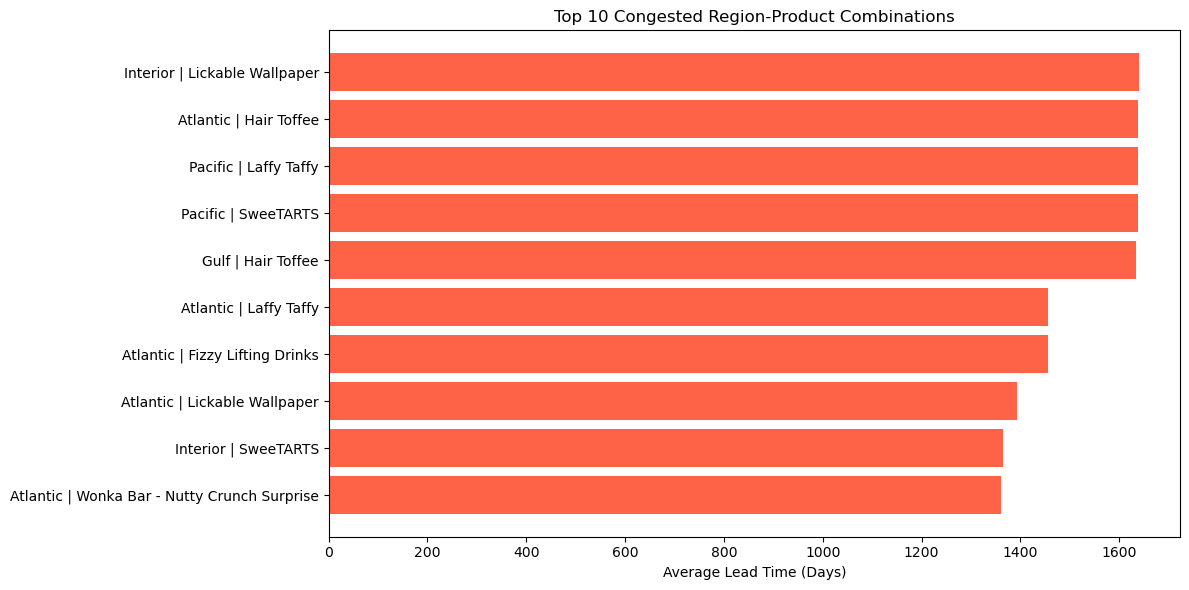

In [32]:
plt.figure(figsize=(12,6))
top_congested = congested.head(10)
labels = top_congested["Region"] + " | " + top_congested["Product Name"]
plt.barh(labels, top_congested["Avg_Lead_Time"], color='tomato')
plt.xlabel("Average Lead Time (Days)")
plt.title("Top 10 Congested Region-Product Combinations")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

In [33]:
all_factories       = list(factory_coordinates.keys())
available_regions   = encoders["Region"].classes_.tolist()
available_shipmodes = encoders["Ship Mode"].classes_.tolist()

print("Factories    :", all_factories)
print("Regions      :", available_regions)
print("Ship Modes   :", available_shipmodes)

Factories    : ["Lot's O' Nuts", "Wicked Choccy's", 'Sugar Shack', 'Secret Factory', 'The Other Factory']
Regions      : ['Atlantic', 'Gulf', 'Interior', 'Pacific']
Ship Modes   : ['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [34]:
def simulate_factory_reassignment(product_name, region, ship_mode):
    results     = []
    product_row = df[df["Product Name"] == product_name].iloc[0]

    for factory in all_factories:
        input_data = {
            "Ship Mode"        : encoders["Ship Mode"].transform([ship_mode])[0],
            "Country/Region"   : encoders["Country/Region"].transform([product_row["Country/Region"]])[0],
            "City"             : encoders["City"].transform([product_row["City"]])[0],
            "State/Province"   : encoders["State/Province"].transform([product_row["State/Province"]])[0],
            "Postal Code"      : encoders["Postal Code"].transform([product_row["Postal Code"]])[0],
            "Division"         : encoders["Division"].transform([product_row["Division"]])[0],
            "Region"           : encoders["Region"].transform([region])[0],
            "Product ID"       : encoders["Product ID"].transform([product_row["Product ID"]])[0],
            "Product Name"     : encoders["Product Name"].transform([product_name])[0],
            "Sales"            : product_row["Sales"],
            "Units"            : product_row["Units"],
            "Gross Profit"     : product_row["Gross Profit"],
            "Cost"             : product_row["Cost"],
            "Month"            : product_row["Month"],
            "Year"             : product_row["Year"],
            "Quarter"          : product_row["Quarter"],
            "Profit Margin"    : product_row["Profit Margin"],
            "Factory Latitude" : factory_coordinates[factory][0],
            "Factory Longitude": factory_coordinates[factory][1],
            "Cluster"          : int(product_row["Cluster"]),
            "Cluster Name"     : int(product_row["Cluster"])
        }
        input_df = pd.DataFrame([input_data])
        input_df = input_df[X_train.columns]          # match column order
        input_df[scale_cols] = scaler.transform(input_df[scale_cols])
        predicted_lead_time  = rf.predict(input_df)[0]

        results.append({
            "Factory"                    : factory,
            "Predicted Lead Time (Days)" : round(predicted_lead_time, 2)
        })

    return pd.DataFrame(results).sort_values(
        "Predicted Lead Time (Days)").reset_index(drop=True)

print("Simulation function ready!")

Simulation function ready!


In [35]:
sim_result = simulate_factory_reassignment(
    product_name = "Nerds",
    region       = available_regions[0],
    ship_mode    = available_shipmodes[0]
)
print(f"Simulation: Nerds | {available_regions[0]} | {available_shipmodes[0]}")
print(sim_result)

Simulation: Nerds | Atlantic | First Class
             Factory  Predicted Lead Time (Days)
0  The Other Factory                     1067.11
1    Wicked Choccy's                     1070.83
2     Secret Factory                     1078.05
3      Lot's O' Nuts                     1078.06
4        Sugar Shack                     1085.38


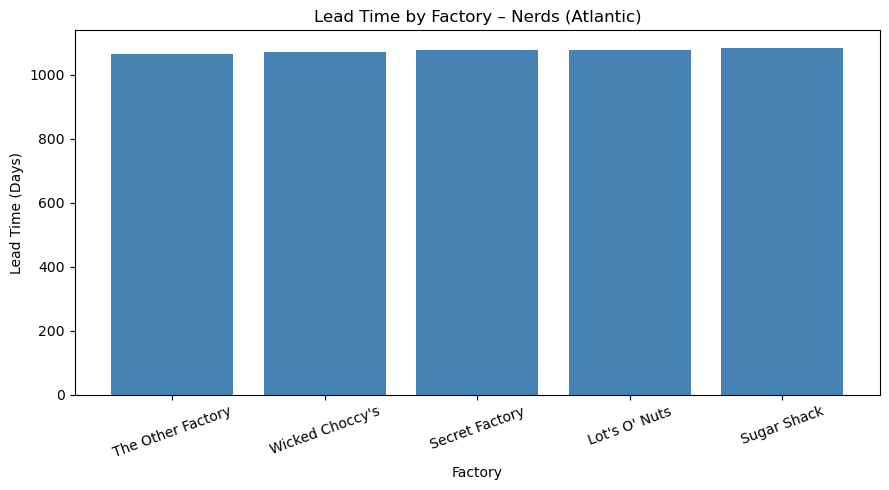

In [36]:
plt.figure(figsize=(9,5))
plt.bar(sim_result["Factory"],
        sim_result["Predicted Lead Time (Days)"], color='steelblue')
plt.title(f"Lead Time by Factory – Nerds ({available_regions[0]})")
plt.xlabel("Factory"); plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

In [37]:
profit_sensitivity = df.groupby("Factory").agg(
    Avg_Profit_Margin = ("Profit Margin","mean"),
    Std_Profit_Margin = ("Profit Margin","std"),
    Total_Gross_Profit= ("Gross Profit","sum"),
    Order_Count       = ("Order ID","count")
).reset_index().round(2)

print("Profit Sensitivity by Factory:")
print(profit_sensitivity.to_string(index=False))

Profit Sensitivity by Factory:
          Factory  Avg_Profit_Margin  Std_Profit_Margin  Total_Gross_Profit  Order_Count
    Lot's O' Nuts              69.18               1.88            49241.05         5558
   Secret Factory              51.93               0.36              314.95          119
      Sugar Shack              53.23               8.34              121.23           33
The Other Factory              12.88              18.53               88.25           54
  Wicked Choccy's              65.12               0.20            32797.79         4019


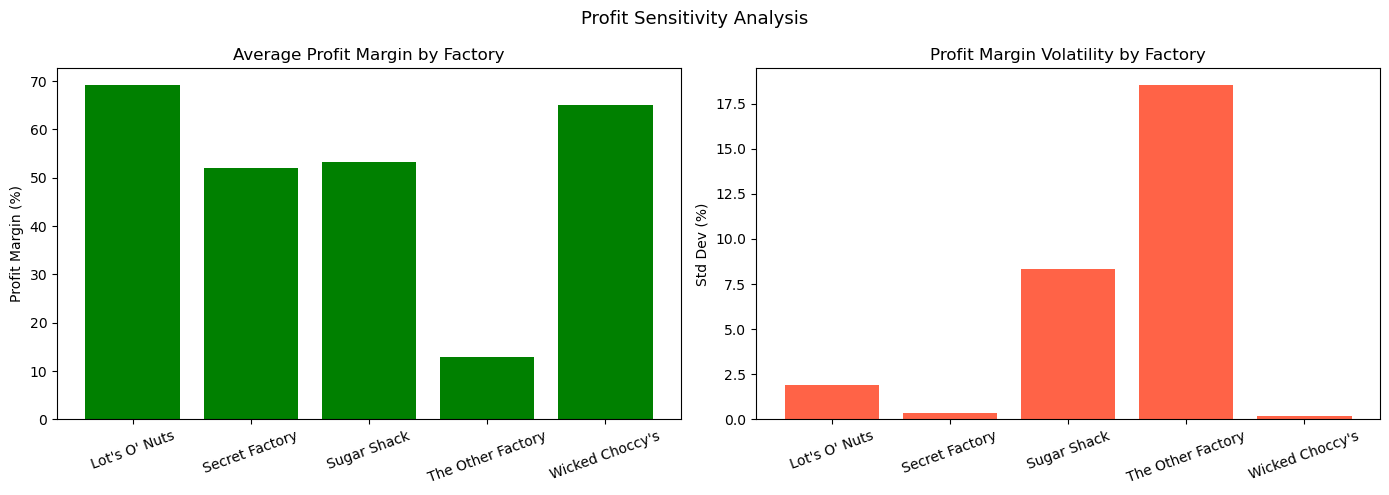

In [38]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].bar(profit_sensitivity["Factory"],
            profit_sensitivity["Avg_Profit_Margin"], color='green')
axes[0].set_title("Average Profit Margin by Factory")
axes[0].set_ylabel("Profit Margin (%)")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(profit_sensitivity["Factory"],
            profit_sensitivity["Std_Profit_Margin"], color='tomato')
axes[1].set_title("Profit Margin Volatility by Factory")
axes[1].set_ylabel("Std Dev (%)")
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle("Profit Sensitivity Analysis", fontsize=13)
plt.tight_layout(); plt.show()

In [39]:
all_products    = list(factory_mapping.keys())
recommendations = []

for product in all_products:
    try:
        sim             = simulate_factory_reassignment(
                              product, available_regions[0], available_shipmodes[0])
        best            = sim.iloc[0]
        current_factory = factory_mapping[product]
        current_row     = sim[sim["Factory"] == current_factory]
        if current_row.empty: continue

        current_lt  = current_row["Predicted Lead Time (Days)"].values[0]
        best_lt     = best["Predicted Lead Time (Days)"]
        improvement = round(current_lt - best_lt, 2)

        recommendations.append({
            "Product"              : product,
            "Current Factory"      : current_factory,
            "Recommended Factory"  : best["Factory"],
            "Current Lead Time"    : current_lt,
            "Recommended Lead Time": best_lt,
            "Improvement (Days)"   : improvement,
            "Should Reassign"      : "Yes" if best["Factory"] != current_factory else "No"
        })
    except Exception as e:
        print(f"Skipped {product}: {e}")

recommendations_df = pd.DataFrame(recommendations).sort_values(
    "Improvement (Days)", ascending=False).reset_index(drop=True)
print(f"Recommendations for {len(recommendations_df)} products!")
recommendations_df

Skipped Everlasting Gobstopper: single positional indexer is out-of-bounds
Recommendations for 14 products!


,Product,Current Factory,Recommended Factory,Current Lead Time,Recommended Lead Time,Improvement (Days),Should Reassign
0,Nerds,Sugar Shack,The Other Factory,1085.38,1067.11,18.27,Yes
1,Lickable Wallpaper,Secret Factory,Wicked Choccy's,1171.32,1156.60,14.72,Yes
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1107.99,1100.69,7.30,Yes
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1134.07,1130.40,3.67,Yes
4,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,1100.86,1097.20,3.66,Yes
5,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1031.88,1029.40,2.48,Yes
6,Laffy Taffy,Sugar Shack,Lot's O' Nuts,976.16,976.07,0.09,Yes
7,Wonka Gum,Secret Factory,The Other Factory,1079.01,1078.99,0.02,Yes
8,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Wicked Choccy's,1046.34,1046.34,0.00,No
9,SweeTARTS,Sugar Shack,Sugar Shack,1038.73,1038.73,0.00,No


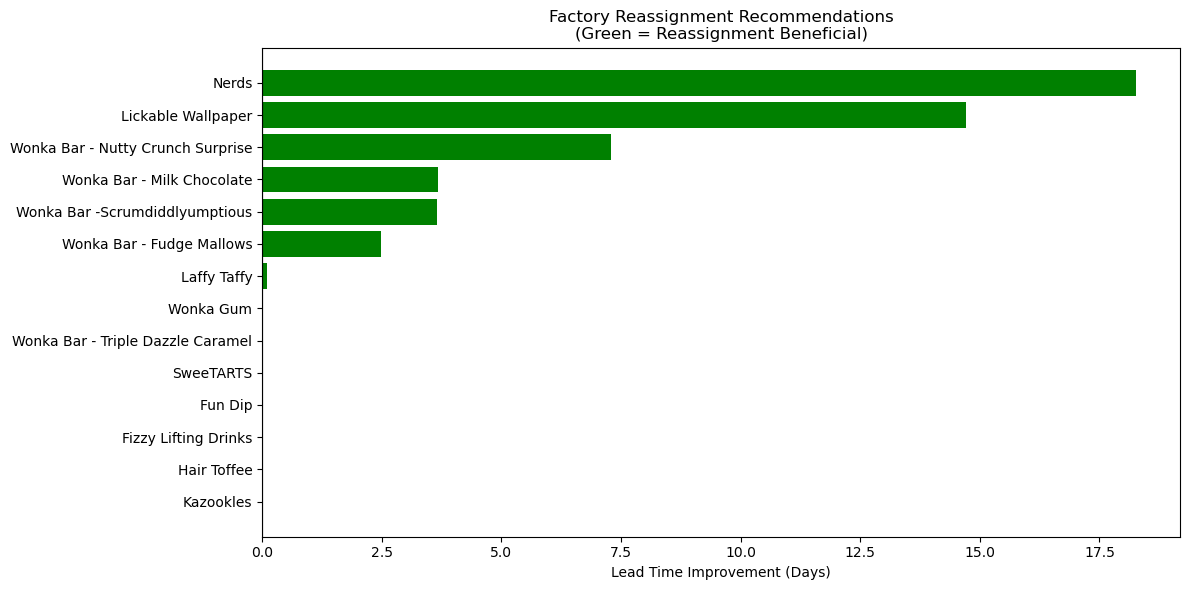

In [40]:
plt.figure(figsize=(12,6))
colors = ['green' if x > 0 else 'gray'
          for x in recommendations_df["Improvement (Days)"]]
plt.barh(recommendations_df["Product"],
         recommendations_df["Improvement (Days)"], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel("Lead Time Improvement (Days)")
plt.title("Factory Reassignment Recommendations\n(Green = Reassignment Beneficial)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

In [41]:
reassign = recommendations_df[recommendations_df["Should Reassign"] == "Yes"]
print(f"Products to reassign: {len(reassign)}")
print()
print(reassign[["Product","Current Factory",
                "Recommended Factory","Improvement (Days)"]].to_string(index=False))

Products to reassign: 10

                          Product   Current Factory Recommended Factory  Improvement (Days)
                            Nerds       Sugar Shack   The Other Factory               18.27
               Lickable Wallpaper    Secret Factory     Wicked Choccy's               14.72
Wonka Bar - Nutty Crunch Surprise     Lot's O' Nuts     Wicked Choccy's                7.30
       Wonka Bar - Milk Chocolate   Wicked Choccy's   The Other Factory                3.67
   Wonka Bar -Scrumdiddlyumptious     Lot's O' Nuts     Wicked Choccy's                3.66
        Wonka Bar - Fudge Mallows     Lot's O' Nuts     Wicked Choccy's                2.48
                      Laffy Taffy       Sugar Shack       Lot's O' Nuts                0.09
                        Wonka Gum    Secret Factory   The Other Factory                0.02
             Fizzy Lifting Drinks       Sugar Shack       Lot's O' Nuts                0.00
                        Kazookles The Other Factory   

In [42]:
avg_improvement      = recommendations_df["Improvement (Days)"].mean()
lead_time_reduction  = (avg_improvement /
                        recommendations_df["Current Lead Time"].mean()) * 100
profit_stability     = 100 - df["Profit Margin"].std()
scenario_confidence  = round(rf_r2 * 100, 2)
recommendation_cov   = round((len(recommendations_df) / len(all_products)) * 100, 2)

kpi_df = pd.DataFrame({
    "KPI"  : ["Lead Time Reduction (%)",
               "Profit Impact Stability",
               "Scenario Confidence Score",
               "Recommendation Coverage (%)"],
    "Value": [round(lead_time_reduction, 2),
               round(profit_stability,   2),
               scenario_confidence,
               recommendation_cov]
})

print("=" * 50)
print("      KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 50)
for _, row in kpi_df.iterrows():
    print(f"  {row['KPI']:<32}: {row['Value']}")
print("=" * 50)

      KEY PERFORMANCE INDICATORS (KPIs)
  Lead Time Reduction (%)         : 0.32
  Profit Impact Stability         : 94.72
  Scenario Confidence Score       : 58.98
  Recommendation Coverage (%)     : 93.33


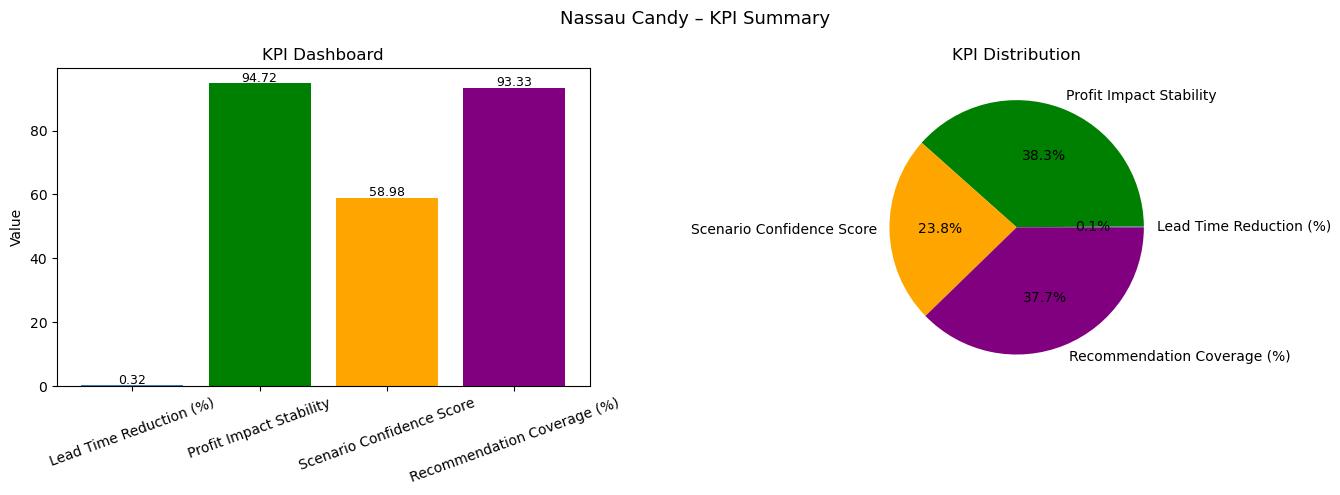

In [43]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].bar(kpi_df["KPI"], kpi_df["Value"],
            color=['steelblue','green','orange','purple'])
axes[0].set_title("KPI Dashboard")
axes[0].set_ylabel("Value")
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(kpi_df["Value"]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=9)

axes[1].pie(kpi_df["Value"],
            labels=kpi_df["KPI"],
            autopct='%1.1f%%',
            colors=['steelblue','green','orange','purple'])
axes[1].set_title("KPI Distribution")

plt.suptitle("Nassau Candy – KPI Summary", fontsize=13)
plt.tight_layout(); plt.show()

In [45]:
with open("random_forest_model.pkl",  "wb") as f: pickle.dump(rf,                  f)
with open("scaler.pkl",              "wb") as f: pickle.dump(scaler,              f)
with open("label_encoders.pkl",      "wb") as f: pickle.dump(encoders,            f)
with open("factory_mapping.pkl",     "wb") as f: pickle.dump(factory_mapping,     f)
with open("factory_coordinates.pkl", "wb") as f: pickle.dump(factory_coordinates, f)

recommendations_df.to_csv("recommendations.csv", index=False)
df.to_csv("Nassau_Candy_Cleaned.csv",            index=False)

saved = ["random_forest_model.pkl","scaler.pkl","label_encoders.pkl",
         "factory_mapping.pkl","factory_coordinates.pkl",
         "recommendations.csv","Nassau_Candy_Cleaned.csv"]

print("Files saved:")
for fn in saved:
    print(f"  {'✅' if os.path.exists(fn) else '❌'} {fn}")

Files saved:
  ✅ random_forest_model.pkl
  ✅ scaler.pkl
  ✅ label_encoders.pkl
  ✅ factory_mapping.pkl
  ✅ factory_coordinates.pkl
  ✅ recommendations.csv
  ✅ Nassau_Candy_Cleaned.csv


In [46]:
print(df['Lead Time'].describe())

count    9783.000000
mean     1321.240008
std       262.059556
min       904.000000
25%      1271.000000
50%      1274.000000
75%      1638.000000
max      1642.000000
Name: Lead Time, dtype: float64


In [47]:
print(df['Order Date'].head())
print(df['Ship Date'].head())

0   2024-01-03
1   2024-01-04
2   2024-01-04
3   2024-01-04
4   2024-01-05
Name: Order Date, dtype: datetime64[ns]
0   2026-06-30
1   2026-07-01
2   2026-07-01
3   2026-07-01
4   2026-07-05
Name: Ship Date, dtype: datetime64[ns]


In [48]:
df_raw = pd.read_csv(r"C:\Users\Rikku\Downloads\Nassau Candy Distributor.csv")
print("Original Order Date:", df_raw['Order Date'].head())
print("Original Ship Date:", df_raw['Ship Date'].head())



Original Order Date: 0    03-01-2024
1    04-01-2024
2    04-01-2024
3    04-01-2024
4    05-01-2024
Name: Order Date, dtype: object
Original Ship Date: 0    30-06-2026
1    01-07-2026
2    01-07-2026
3    01-07-2026
4    05-07-2026
Name: Ship Date, dtype: object


In [49]:
df = df[df['Lead Time'] > 0]
df = df[df['Lead Time'] < 365]  # 1 saal se kam

print("Fixed Lead Time:")
print(df['Lead Time'].describe())

df.to_csv('Nassau_Candy_Cleaned.csv', index=False)
print("CSV Updated!")

Fixed Lead Time:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Lead Time, dtype: float64
CSV Updated!


In [51]:
df = pd.read_csv(r"C:\Users\Rikku\Downloads\Nassau Candy Distributor.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Lead Time Stats:")
print(df['Lead Time'].describe())

 
df = df[df['Lead Time'] > 0]
print("\nAfter filtering negatives:", df.shape)

df.to_csv('Nassau_Candy_Cleaned.csv', index=False)
print("Saved!")

Lead Time Stats:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

After filtering negatives: (10194, 19)
Saved!
